In [1]:
import pandas as pd
import os

# Load the dataset
import kagglehub
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

# 1. Define the file paths
true_path = os.path.join(path, "True.csv")
fake_path = os.path.join(path, "Fake.csv")

# 2. Load the datasets
df_true = pd.read_csv(true_path)
df_fake = pd.read_csv(fake_path)

# 3. Create the 'target' label
# We assign 0 to Real news and 1 to Fake news
df_true['target'] = 0
df_fake['target'] = 1

# 4. Concatenate (combine) them into one dataframe
df = pd.concat([df_true, df_fake], axis=0).reset_index(drop=True)

# 5. Shuffle the data
# (Important: otherwise the model sees all real news first, then all fake)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Let's see how many of each we have
print(df['target'].value_counts())
df.head()

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
target
1    23481
0    21417
Name: count, dtype: int64


,title,text,subject,date,target
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",1
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",1
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",1
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",0
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",1


In [2]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download necessary resources
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize Lemmatizer and Stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Combine Title and Text into one column
df['full_text'] = df['title'] + " " + df['text']

def preprocess_text(text):

  # Lowercase and Remove non-alphabetical characters
  text = re.sub(r'[^a-zA-Z\s]', '', text.lower())

  # Tokenize
  tokens = word_tokenize(text)

  # Remove stopwords and Lemmatize
  cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

  return " ".join(cleaned_tokens)


# Apply Preprocessing on the full text
df['cleaned_content'] = df['full_text'].apply(preprocess_text)

print("Preprocessing Complete")
print(df[['full_text', 'cleaned_content', 'target']].head())


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Preprocessing Complete
                                           full_text  \
0   BREAKING: GOP Chairman Grassley Has Had Enoug...   
1   Failed GOP Candidates Remembered In Hilarious...   
2   Mike Pence’s New DC Neighbors Are HILARIOUSLY...   
3  California AG pledges to defend birth control ...   
4  AZ RANCHERS Living On US-Mexico Border Destroy...   

                                     cleaned_content  target  
0  breaking gop chairman grassley enough demand t...       1  
1  failed gop candidate remembered hilarious mock...       1  
2  mike pences new dc neighbor hilariously trolli...       1  
3  california ag pledge defend birth control insu...       0  
4  az rancher living usmexico border destroy nanc...       1  


In [4]:
# Vectorization

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Split data into Training and Testing sets
X = df['cleaned_content']
y = df['target']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Initialize and fit TF-IDF
tfidf = TfidfVectorizer(max_features=5000)

X_train = tfidf.fit_transform(X_train_raw)
X_test = tfidf.transform(X_test_raw)

print(f"Vectorization complete. Training shape: {X_train.shape}")

Vectorization complete. Training shape: (35918, 5000)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# Train Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Train SVM (LinearSVC is faster for large text datasets)
svm_model = LinearSVC(max_iter=1000)
svm_model.fit(X_train, y_train)

print("Both models have been trained successfully!")

Both models have been trained successfully!


In [6]:
# Getting predictions for both
log_preds = log_model.predict(X_test)
svm_preds = svm_model.predict(X_test)

# Show a quick comparison of the first 5 results
print(f"Actual Labels:    {y_test[:5].values}")
print(f"LogReg Predicts: {log_preds[:5]}")
print(f"SVM Predicts:    {svm_preds[:5]}")

Actual Labels:    [0 1 1 0 1]
LogReg Predicts: [0 1 1 0 1]
SVM Predicts:    [0 1 1 0 1]


In [7]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Calculate metrics for Logistic Regression
log_acc = accuracy_score(y_test, log_preds)
log_f1 = f1_score(y_test, log_preds)

# Calculate metrics for SVM
svm_acc = accuracy_score(y_test, svm_preds)
svm_f1 = f1_score(y_test, svm_preds)

# Display the results in a clean table
import pandas as pd
results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Score'],
    'Logistic Regression': [f"{log_acc:.4f}", f"{log_f1:.4f}"],
    'SVM': [f"{svm_acc:.4f}", f"{svm_f1:.4f}"]
})

print(results)

     Metric Logistic Regression     SVM
0  Accuracy              0.9871  0.9950
1  F1-Score              0.9875  0.9952


In [8]:
print("\n--- Logistic Regression Detailed Report ---")
print(classification_report(y_test, log_preds, target_names=['Real', 'Fake']))

print("\n--- SVM Detailed Report ---")
print(classification_report(y_test, svm_preds, target_names=['Real', 'Fake']))


--- Logistic Regression Detailed Report ---
              precision    recall  f1-score   support

        Real       0.98      0.99      0.99      4311
        Fake       0.99      0.98      0.99      4669

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980


--- SVM Detailed Report ---
              precision    recall  f1-score   support

        Real       0.99      1.00      0.99      4311
        Fake       1.00      0.99      1.00      4669

    accuracy                           0.99      8980
   macro avg       0.99      1.00      0.99      8980
weighted avg       0.99      0.99      0.99      8980



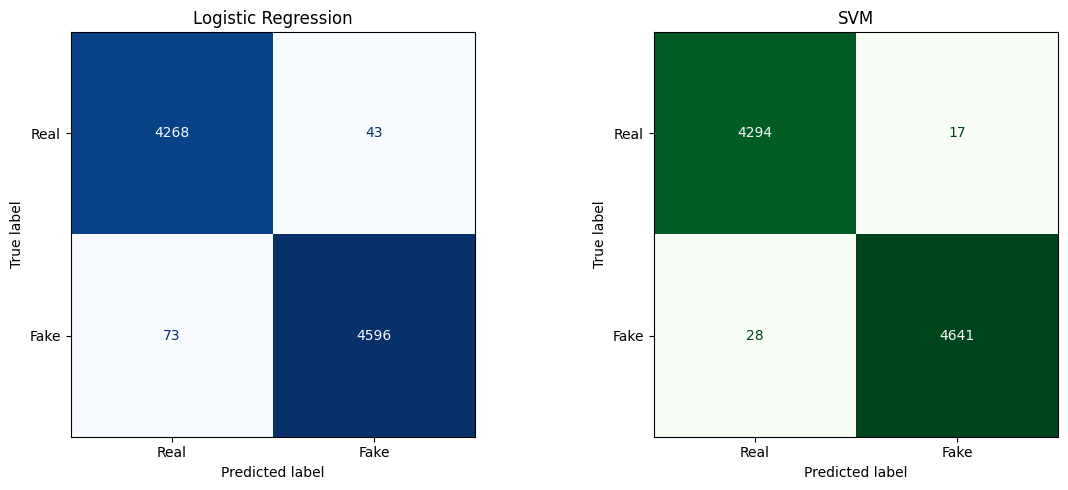

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 2. Plot Logistic Regression Matrix
log_cm = confusion_matrix(y_test, log_preds)
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, display_labels=['Real', 'Fake'])
log_disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Logistic Regression')

# 3. Plot SVM Matrix
svm_cm = confusion_matrix(y_test, svm_preds)
svm_disp = ConfusionMatrixDisplay(confusion_matrix=svm_cm, display_labels=['Real', 'Fake'])
svm_disp.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('SVM')

plt.tight_layout()
plt.show()

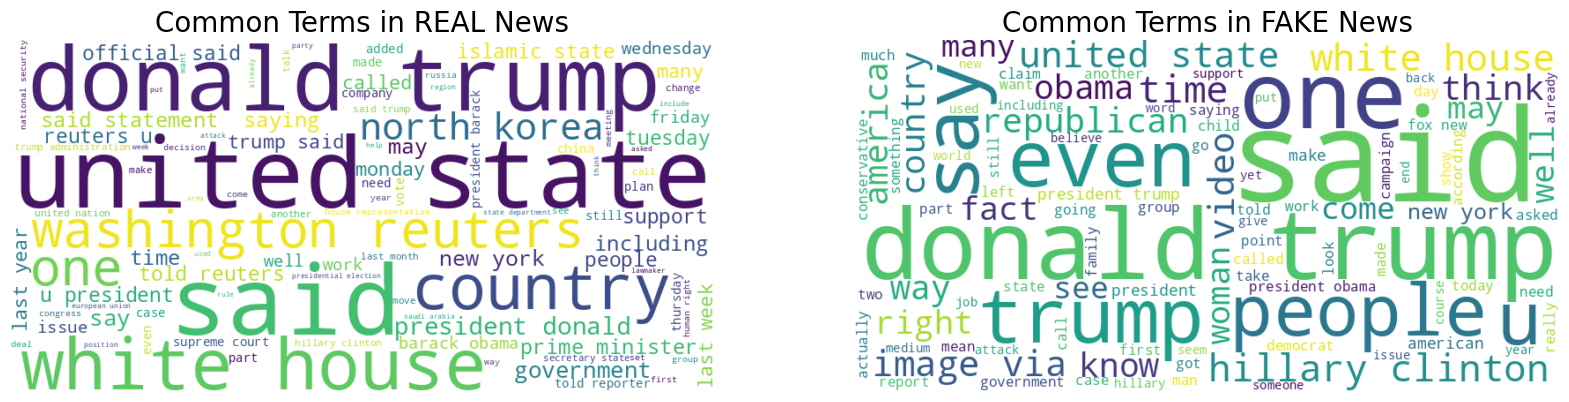

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Separate the cleaned text for each class
real_news_text = " ".join(df[df['target'] == 0]['cleaned_content'])
fake_news_text = " ".join(df[df['target'] == 1]['cleaned_content'])

# 2. Setup the WordCloud object
# We use a white background to make the colors pop
wc = WordCloud(width=800, height=400, background_color='white', max_words=100)

# 3. Generate and Plot
plt.figure(figsize=(20, 10))

# Real News Word Cloud
plt.subplot(1, 2, 1)
real_wc = wc.generate(real_news_text)
plt.imshow(real_wc, interpolation='bilinear')
plt.title('Common Terms in REAL News', fontsize=20)
plt.axis('off')

# Fake News Word Cloud
plt.subplot(1, 2, 2)
fake_wc = wc.generate(fake_news_text)
plt.imshow(fake_wc, interpolation='bilinear')
plt.title('Common Terms in FAKE News', fontsize=20)
plt.axis('off')

plt.show()